<a href="https://colab.research.google.com/github/melissa-04/tubitak-2209a-spatial-stemness-emt/blob/main/08_cell_vs_spot_control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q scanpy statsmodels "pandas==2.3.3"

from google.colab import drive
drive.mount('/content/drive')

import os, sys
import scanpy as sc, pandas as pd, numpy as np, scipy
from scipy.stats import spearmanr, wilcoxon
sc.settings.verbosity = 0

BASE    = '/content/drive/MyDrive/Tubitak-2209a'
RESULTS = f'{BASE}/04_results'
FIGURES = f'{BASE}/05_figures'
os.makedirs(RESULTS, exist_ok=True)
print(f'scanpy {sc.__version__} | pandas {pd.__version__} | numpy {np.__version__}')

adata = sc.read_h5ad(f'{BASE}/02_scRNA_analysis/scrna_filtered.h5ad')
cyto  = pd.read_csv(f'{BASE}/02_scRNA_analysis/cytotrace2_epithelial_results.csv', index_col=0)
spot  = pd.read_csv(f'{BASE}/03_spatial_analysis/spatial_all_scores.csv')
print(f'\nscRNA  : {adata.shape[0]} cells x {adata.shape[1]} genes')
print(f'CT2    : {cyto.shape[0]} cells')
print(f'spots  : {spot.shape[0]} ({spot.spatial_stemness.notna().sum()} with stemness)')

PURAM = ["SERPINE1","TGFBI","MMP10","LAMC2","P4HA2","PDPN","ITGA5","LAMA3","CDH13","TNC",
"MMP2","EMP3","INHBA","LAMB3","VIM","SEMA3C","CAVIN3","ANXA5","DHRS7","ITGB1","ACTN1",
"ACKR3","ITGB6","IGFBP7","THBS1","PTHLH","TNFRSF6B","PDLIM7","CAV1","DKK3","COL17A1",
"LTBP1","COL5A2","COL1A1","FHL2","TIMP3","PLAU","LGALS1","PSMD2","CD63","HERPUD1","TPM1",
"SLC39A14","C1S","MMP1","EXT2","COL4A2","PRSS23","SLC7A8","SLC31A2","ARPC1B","APP","MFAP2",
"MPZL1","GSDME","MT2A","MAGED2","ITGA6","FSTL1","TNFRSF12A","IL32","COPB2","PTK7","OCIAD2",
"TAX1BP3","SEC13","SERPINH1","TPM4","MYH9","ANXA8L1","PLOD2","GALNT2","P3H2","MAGED1",
"SLC38A5","FSTL3","CD99","F3","PSAP","NMRK1","FKBP9","DSG2","ECM1","HTRA1","SERINC1","CALU",
"TPST1","PLOD3","IGFBP3","FRMD6","CXCL14","SERPINE2","RABAC1","TMED9","NAGK","BMP1","ESYT1",
"STON2","TAGLN","GJA1"]

try:
    import gseapy
except ImportError:
    !pip install -q gseapy
    import gseapy
HALLMARK = gseapy.get_library("MSigDB_Hallmark_2020")["Epithelial Mesenchymal Transition"]
print(f'\nHallmark EMT genes fetched: {len(HALLMARK)}')

SIGS = {'pEMT_puram': PURAM, 'EMT_hallmark': HALLMARK}
for name, genes in SIGS.items():
    found = [g for g in genes if g in adata.var_names]
    print(f'  {name:14s} {len(found)}/{len(genes)} genes present in scRNA')

epi = adata[adata.obs.celltype_major.isin(['Cancer Epithelial', 'Normal Epithelial'])].copy()
epi.obs['CT2'] = cyto.reindex(epi.obs_names)['CytoTRACE2_Score'].values
print(f'\nEpithelial subset: {epi.shape[0]} cells, '
      f'{epi.obs.CT2.notna().sum()} with CytoTRACE 2 score')
print(f'  Cancer Epithelial: {(epi.obs.celltype_major == "Cancer Epithelial").sum()}')
print(f'  Normal Epithelial: {(epi.obs.celltype_major == "Normal Epithelial").sum()}')

MATCHED = {'CID4290A': 'CID4290', 'CID4465': 'CID4465',
           'CID44971': 'CID44971', 'CID4535': 'CID4535'}
print(f'\nPatients matched to spatial data: {list(MATCHED.keys())}')
print(f'Total scRNA patients with epithelium: '
      f'{epi.obs.groupby("orig.ident", observed=True).size().gt(0).sum()}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.2/190.2 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas=

/tmp/ipykernel_1358/1857497559.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f'scanpy {sc.__version__} | pandas {pd.__version__} | numpy {np.__version__}')


scanpy 1.12.4 | pandas 2.3.3 | numpy 2.1.3

scRNA  : 100064 cells x 29733 genes
CT2    : 28844 cells
spots  : 15611 (10263 with stemness)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.7/689.7 kB 10.4 MB/s eta 0:00:00

Hallmark EMT genes fetched: 200
  pEMT_puram     97/100 genes present in scRNA
  EMT_hallmark   198/200 genes present in scRNA

Epithelial subset: 28844 cells, 28844 with CytoTRACE 2 score
  Cancer Epithelial: 24489
  Normal Epithelial: 4355

Patients matched to spatial data: ['CID4290A', 'CID4465', 'CID44971', 'CID4535']
Total scRNA patients with epithelium: 22


In [ ]:
sc.pp.normalize_total(epi, target_sum=1e4)
sc.pp.log1p(epi)
print(f'Normalized: max {epi.X.max():.3f}')

for name, genes in SIGS.items():
    present = [g for g in genes if g in epi.var_names]
    sc.tl.score_genes(epi, gene_list=present, score_name=name,
                      ctrl_size=50, random_state=42, use_raw=False)
    v = epi.obs[name]
    print(f'  {name:14s} mean={v.mean():+.4f}  median={v.median():+.4f}  '
          f'sd={v.std():.4f}  range[{v.min():+.3f},{v.max():+.3f}]')

cells = pd.DataFrame({
    'CT2':      epi.obs.CT2.values,
    'patient':  epi.obs['orig.ident'].values,
    'celltype': epi.obs.celltype_major.values,
    'subtype':  epi.obs.subtype.values,
    **{s: epi.obs[s].values for s in SIGS}
}, index=epi.obs_names).dropna(subset=['CT2'])

print(f'\nCell table: {len(cells)} cells, {cells.patient.nunique()} patients')

print('\n--- SANITY: do cell-level scores behave sensibly? ---')
for name in SIGS:
    nor = cells[cells.celltype == 'Normal Epithelial'][name]
    can = cells[cells.celltype == 'Cancer Epithelial'][name]
    print(f'  {name:14s} Normal={nor.median():+.4f}  Cancer={can.median():+.4f}')

print('\n--- Spot-level score distributions for comparison ---')
for name in SIGS:
    v = spot[name]
    print(f'  {name:14s} mean={v.mean():+.4f}  median={v.median():+.4f}  sd={v.std():.4f}')

cells.to_csv(f'{RESULTS}/cell_level_scores.csv')
print(f'\nSaved -> {RESULTS}/cell_level_scores.csv')

Normalized: max 9.009
  pEMT_puram     mean=+0.1519  median=+0.1261  sd=0.1288  range[-0.116,+1.119]
  EMT_hallmark   mean=+0.0731  median=+0.0503  sd=0.0941  range[-0.089,+0.944]

Cell table: 28844 cells, 22 patients

--- SANITY: do cell-level scores behave sensibly? ---
  pEMT_puram     Normal=+0.1688  Cancer=+0.1205
  EMT_hallmark   Normal=+0.1073  Cancer=+0.0440

--- Spot-level score distributions for comparison ---
  pEMT_puram     mean=+0.3321  median=+0.3142  sd=0.1277
  EMT_hallmark   mean=+0.2715  median=+0.2498  sd=0.1416

Saved -> /content/drive/MyDrive/Tubitak-2209a/04_results/cell_level_scores.csv


In [ ]:
def within_patient_rho(frame, x, y, group, min_n=100):
    out = []
    for g, sub in frame.groupby(group, observed=True):
        if len(sub) < min_n:
            continue
        r = spearmanr(sub[x], sub[y])[0]
        if not np.isnan(r):
            out.append((g, len(sub), r))
    return out

rows = []
for sig in SIGS:
    layers = {
        'cell_all_epithelium': within_patient_rho(cells, 'CT2', sig, 'patient'),
        'cell_cancer_only':    within_patient_rho(cells[cells.celltype == 'Cancer Epithelial'],
                                                  'CT2', sig, 'patient'),
        'cell_matched_4':      within_patient_rho(cells[cells.patient.isin(MATCHED)],
                                                  'CT2', sig, 'patient'),
        'spot':                within_patient_rho(spot[spot.spatial_stemness.notna()],
                                                  'spatial_stemness', sig, 'patientid'),
    }
    for lbl, res in layers.items():
        rs = [r for _, _, r in res]
        try:
            wp = wilcoxon(rs)[1]
        except Exception:
            wp = np.nan
        rows.append({'signature': sig, 'level': lbl, 'n_units': len(rs),
                     'median_rho': round(np.median(rs), 4),
                     'mean_rho': round(np.mean(rs), 4),
                     'n_positive': f'{sum(r > 0 for r in rs)}/{len(rs)}',
                     'wilcoxon_p': round(wp, 4),
                     'rho_min': round(min(rs), 3), 'rho_max': round(max(rs), 3)})

scale = pd.DataFrame(rows)
print('--- STEMNESS x EMT AT TWO SCALES ---\n')
for sig in SIGS:
    print(f'{sig}:')
    print(scale[scale.signature == sig].drop(columns='signature').to_string(index=False))
    print()

print('--- PER-PATIENT DETAIL: matched patients, cell vs spot ---\n')
detail = []
for sig in SIGS:
    cell_r = dict((p, r) for p, _, r in within_patient_rho(cells, 'CT2', sig, 'patient'))
    spot_r = dict((p, r) for p, _, r in within_patient_rho(
        spot[spot.spatial_stemness.notna()], 'spatial_stemness', sig, 'patientid'))
    for sc_pat, sp_pat in MATCHED.items():
        detail.append({'signature': sig, 'scRNA_patient': sc_pat, 'spatial_patient': sp_pat,
                       'cell_rho': round(cell_r.get(sc_pat, np.nan), 3),
                       'spot_rho': round(spot_r.get(sp_pat, np.nan), 3),
                       'difference': round(spot_r.get(sp_pat, np.nan) - cell_r.get(sc_pat, np.nan), 3)})
dt = pd.DataFrame(detail)
print(dt.to_string(index=False))

scale.to_csv(f'{RESULTS}/scale_comparison.csv', index=False)
dt.to_csv(f'{RESULTS}/scale_matched_patients.csv', index=False)
print(f'\nSaved -> {RESULTS}/scale_comparison.csv, scale_matched_patients.csv')

--- STEMNESS x EMT AT TWO SCALES ---

pEMT_puram:
              level  n_units  median_rho  mean_rho n_positive  wilcoxon_p  rho_min  rho_max
cell_all_epithelium       22      0.0373    0.1068      13/22      0.1207   -0.296    0.615
   cell_cancer_only       20      0.0286    0.0615      11/20      0.3118   -0.294    0.602
     cell_matched_4        4      0.0992    0.1134        4/4      0.1250    0.058    0.198
               spot        6      0.1962    0.2649        6/6      0.0312    0.125    0.534

EMT_hallmark:
              level  n_units  median_rho  mean_rho n_positive  wilcoxon_p  rho_min  rho_max
cell_all_epithelium       22     -0.0130    0.1008      11/22      0.4434   -0.351    0.809
   cell_cancer_only       20     -0.0130    0.0344      10/20      0.9563   -0.173    0.572
     cell_matched_4        4     -0.0921   -0.0746        1/4      0.3750   -0.199    0.085
               spot        6      0.2619    0.3153        6/6      0.0312    0.110    0.629

--- PER-PATIEN

In [ ]:
rng = np.random.default_rng(42)

print('=== (a) BOOTSTRAP CI FOR THE SCALE DIFFERENCE ===')
print('    resampling patients within each level, 2000 iterations\n')
B = 2000
boot_rows = []
for sig in SIGS:
    cell_rs = np.array([r for _, _, r in within_patient_rho(cells, 'CT2', sig, 'patient')])
    spot_rs = np.array([r for _, _, r in within_patient_rho(
        spot[spot.spatial_stemness.notna()], 'spatial_stemness', sig, 'patientid')])
    diffs = np.array([np.median(rng.choice(spot_rs, len(spot_rs), replace=True)) -
                      np.median(rng.choice(cell_rs, len(cell_rs), replace=True))
                      for _ in range(B)])
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    p_boot = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())
    print(f'  {sig:14s} cell={np.median(cell_rs):+.3f}  spot={np.median(spot_rs):+.3f}  '
          f'diff={np.median(diffs):+.3f}  95%CI[{lo:+.3f},{hi:+.3f}]  p={p_boot:.4f}')
    boot_rows.append({'signature': sig, 'cell_median': round(np.median(cell_rs), 4),
                      'spot_median': round(np.median(spot_rs), 4),
                      'difference': round(np.median(diffs), 4),
                      'ci_low': round(lo, 4), 'ci_high': round(hi, 4),
                      'p_bootstrap': round(p_boot, 4)})

print('\n=== (b) PSEUDO-SPOT CONTROL ===')
print('    does simple averaging of random cells reproduce the effect?')
print('    (if yes, the scale effect is arithmetic; if no, it is spatial)\n')
N_CELLS, N_REP = 8, 50
pseudo_rows = []
for sig in SIGS:
    reps = {}
    for rep in range(N_REP):
        rr = np.random.default_rng(1000 + rep)
        for p, sub in cells.groupby('patient', observed=True):
            if len(sub) < 200:
                continue
            idx = rr.permutation(len(sub))
            n_groups = len(sub) // N_CELLS
            if n_groups < 20:
                continue
            grp = idx[:n_groups * N_CELLS].reshape(n_groups, N_CELLS)
            ps_ct2 = sub.CT2.values[grp].mean(axis=1)
            ps_emt = sub[sig].values[grp].mean(axis=1)
            reps.setdefault(p, []).append(spearmanr(ps_ct2, ps_emt)[0])
    med = {p: np.median(v) for p, v in reps.items()}
    vals = np.array(list(med.values()))
    real_cell = np.median([r for _, _, r in within_patient_rho(cells, 'CT2', sig, 'patient')])
    real_spot = np.median([r for _, _, r in within_patient_rho(
        spot[spot.spatial_stemness.notna()], 'spatial_stemness', sig, 'patientid')])
    print(f'  {sig}')
    print(f'    real cells        : {real_cell:+.3f}')
    print(f'    pseudo-spots (8c) : {np.median(vals):+.3f}   ({sum(vals>0)}/{len(vals)} positive)')
    print(f'    real spots        : {real_spot:+.3f}')
    gain_arith = np.median(vals) - real_cell
    gain_spatial = real_spot - np.median(vals)
    print(f'    -> arithmetic gain from averaging : {gain_arith:+.3f}')
    print(f'    -> additional gain in real spots  : {gain_spatial:+.3f}\n')
    pseudo_rows.append({'signature': sig, 'real_cell': round(real_cell, 4),
                        'pseudo_spot': round(np.median(vals), 4),
                        'real_spot': round(real_spot, 4),
                        'gain_arithmetic': round(gain_arith, 4),
                        'gain_spatial': round(gain_spatial, 4),
                        'n_patients': len(vals)})

pd.DataFrame(boot_rows).to_csv(f'{RESULTS}/scale_bootstrap.csv', index=False)
pd.DataFrame(pseudo_rows).to_csv(f'{RESULTS}/pseudospot_control.csv', index=False)
print(f'Saved -> {RESULTS}/scale_bootstrap.csv, pseudospot_control.csv')

=== (a) BOOTSTRAP CI FOR THE SCALE DIFFERENCE ===
    resampling patients within each level, 2000 iterations

  pEMT_puram     cell=+0.037  spot=+0.196  diff=+0.169  95%CI[+0.057,+0.407]  p=0.0150
  EMT_hallmark   cell=-0.013  spot=+0.262  diff=+0.265  95%CI[+0.020,+0.562]  p=0.0360

=== (b) PSEUDO-SPOT CONTROL ===
    does simple averaging of random cells reproduce the effect?
    (if yes, the scale effect is arithmetic; if no, it is spatial)

  pEMT_puram
    real cells        : +0.037
    pseudo-spots (8c) : +0.076   (12/19 positive)
    real spots        : +0.196
    -> arithmetic gain from averaging : +0.038
    -> additional gain in real spots  : +0.121

  EMT_hallmark
    real cells        : -0.013
    pseudo-spots (8c) : +0.069   (13/19 positive)
    real spots        : +0.262
    -> arithmetic gain from averaging : +0.082
    -> additional gain in real spots  : +0.193

Saved -> /content/drive/MyDrive/Tubitak-2209a/04_results/scale_bootstrap.csv, pseudospot_control.csv


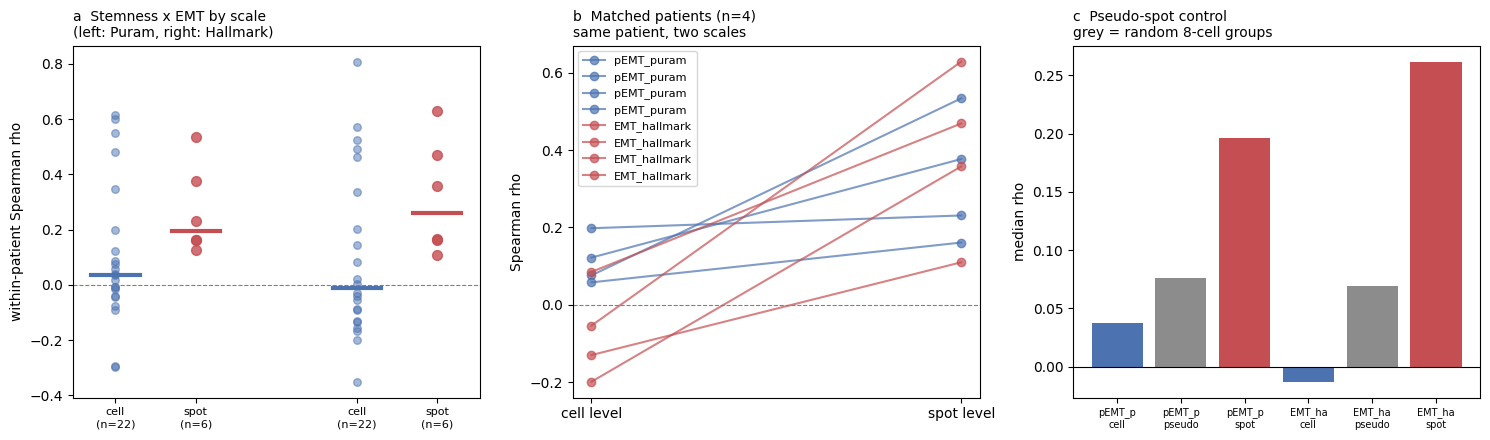

Draft figure saved -> /content/drive/MyDrive/Tubitak-2209a/05_figures/draft_scale_comparison.png
(publication version will be built in step 5)


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
for i, sig in enumerate(SIGS):
    cr = [r for _, _, r in within_patient_rho(cells, 'CT2', sig, 'patient')]
    sr = [r for _, _, r in within_patient_rho(
        spot[spot.spatial_stemness.notna()], 'spatial_stemness', sig, 'patientid')]
    ax.scatter([i * 3 + 0] * len(cr), cr, alpha=.5, s=30, color='#4C72B0')
    ax.scatter([i * 3 + 1] * len(sr), sr, alpha=.8, s=50, color='#C44E52')
    ax.plot([i * 3 - .3, i * 3 + .3], [np.median(cr)] * 2, color='#4C72B0', lw=3)
    ax.plot([i * 3 + .7, i * 3 + 1.3], [np.median(sr)] * 2, color='#C44E52', lw=3)
ax.axhline(0, color='grey', lw=.8, ls='--')
ax.set_xticks([0, 1, 3, 4])
ax.set_xticklabels(['cell\n(n=22)', 'spot\n(n=6)', 'cell\n(n=22)', 'spot\n(n=6)'], fontsize=8)
ax.set_ylabel('within-patient Spearman rho')
ax.set_title('a  Stemness x EMT by scale\n(left: Puram, right: Hallmark)', loc='left', fontsize=10)

ax = axes[1]
w = 0.35
for i, sig in enumerate(SIGS):
    sub = dt[dt.signature == sig]
    x = np.arange(len(sub)) + i * 0.0
    ax.plot([0, 1], [sub.cell_rho.values, sub.spot_rho.values],
            marker='o', color='#4C72B0' if i == 0 else '#C44E52', alpha=.7,
            label=sig if i < 2 else None)
ax.axhline(0, color='grey', lw=.8, ls='--')
ax.set_xticks([0, 1]); ax.set_xticklabels(['cell level', 'spot level'])
ax.set_ylabel('Spearman rho')
ax.set_title('b  Matched patients (n=4)\nsame patient, two scales', loc='left', fontsize=10)
ax.legend(fontsize=8)

ax = axes[2]
labels, vals, colors = [], [], []
for sig in SIGS:
    r = [x for x in pseudo_rows if x['signature'] == sig][0]
    labels += [f'{sig[:6]}\ncell', f'{sig[:6]}\npseudo', f'{sig[:6]}\nspot']
    vals   += [r['real_cell'], r['pseudo_spot'], r['real_spot']]
    colors += ['#4C72B0', '#8C8C8C', '#C44E52']
ax.bar(range(len(vals)), vals, color=colors)
ax.axhline(0, color='black', lw=.8)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel('median rho')
ax.set_title('c  Pseudo-spot control\ngrey = random 8-cell groups', loc='left', fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIGURES}/draft_scale_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Draft figure saved -> {FIGURES}/draft_scale_comparison.png')
print('(publication version will be built in step 5)')